# 02 · Detection — T²/Q vs IsolationForest vs LSTM-AE

Three detectors, fitted on **normal-only** windows, compared at a 1% false-alarm rate.

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import (load_dataset, SyntheticTEPConfig, Standardizer,
                           sliding_windows, train_val_test_split_by_run)
from sensorlab.detection import (PCAMonitor, IForestDetector, LSTMAutoencoder,
                                auroc, threshold_at_far, true_positive_rate,
                                detection_delay)

cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
train_m, val_m, test_m = train_val_test_split_by_run(ds, seed=0)
normal_train = train_m & (ds.fault_id == 0)
normal_val   = val_m & (ds.fault_id == 0)
sc = Standardizer.fit(ds.X[normal_train]); Xz = sc.transform(ds.X)

## Fit detectors

In [3]:
spc = PCAMonitor(var_explained=0.9).fit(Xz[normal_train])
ifo = IForestDetector(n_estimators=200, random_state=0).fit(Xz[normal_train])

windows, _, end_idx = sliding_windows(Xz, ds.run_id, window=20, stride=2)
ae = LSTMAutoencoder(window=20, epochs=15, hidden=24, latent=6).fit(windows[normal_train[end_idx]])
print(f"AE history: {[round(x,4) for x in ae.history[:3]]} ... {[round(x,4) for x in ae.history[-3:]]}")

AE history: [0.9848, 0.9765, 0.966] ... [0.6618, 0.6377, 0.6164]


## ROC + headline numbers

In [4]:
scores = {"PCA-T2Q": spc.score(Xz), "IForest": ifo.score(Xz)}
s_ae_win = ae.score(windows)
s_ae = np.zeros(ds.n_samples, dtype=np.float32); s_ae[end_idx] = s_ae_win
# Forward-fill within each run for consecutive-above-threshold logic
for r in np.unique(ds.run_id):
    m = np.where(ds.run_id == r)[0]
    sub = s_ae[m]; last = 0.0
    for i, v in enumerate(sub):
        if v == 0 and last > 0: sub[i] = last
        else: last = v
    s_ae[m] = sub
scores["LSTM-AE"] = s_ae

from sklearn.metrics import roc_curve
curves = {}; rows = []
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(ds.is_anomaly[test_m], s[test_m])
    curves[name] = (fpr, tpr)
    thr = threshold_at_far(s[normal_val], far=0.01)
    d = detection_delay(s, ds.run_id, ds.run_onsets, ds.run_fault_id, thr,
                        samples_to_minutes=ds.sample_minutes)
    rows.append({"detector": name,
                "AUROC": round(auroc(s[test_m], ds.is_anomaly[test_m]), 3),
                "TPR@FAR=1%": round(true_positive_rate(s[test_m], ds.is_anomaly[test_m], thr), 3),
                "frac_detected": round(d["fraction_detected"], 3),
                "median_delay_min": round(d["median_min"], 1)})
pd.DataFrame(rows).set_index("detector")

,AUROC,TPR@FAR=1%,frac_detected,median_delay_min
detector,,,,
PCA-T2Q,0.757,0.145,0.500,106.5
IForest,0.842,0.391,0.714,45.0
LSTM-AE,0.947,0.517,0.881,51.0


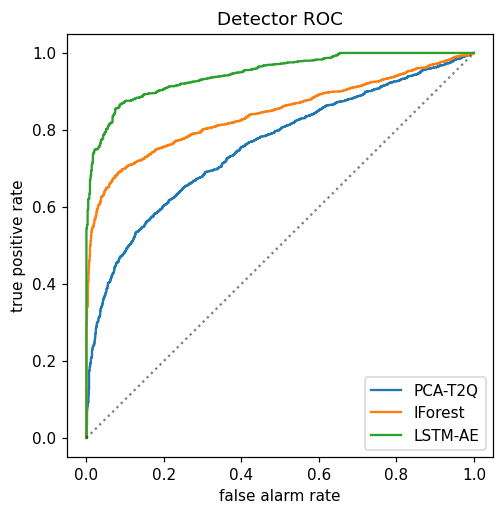

In [5]:
from sensorlab.viz import plot_roc
ax = plot_roc(curves); plt.show()

## Detection score traces on a faulty run

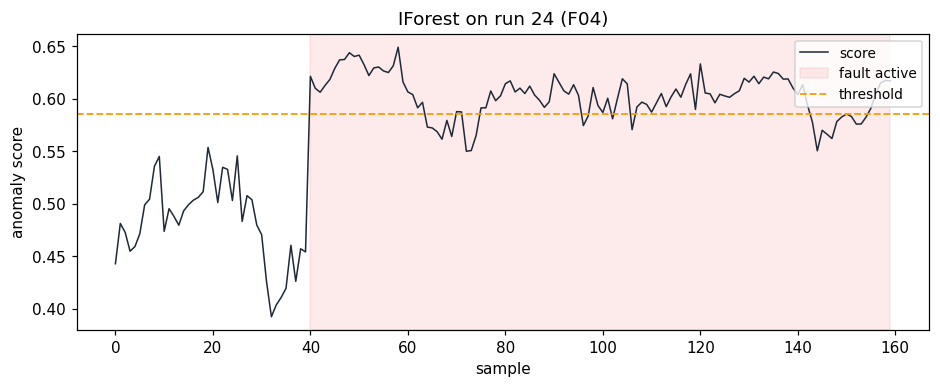

In [6]:
from sensorlab.viz import plot_detection_scores
run = int(np.where(ds.run_fault_id == 4)[0][0])
mask = ds.run_id == run
thr = threshold_at_far(scores["IForest"][normal_val], far=0.01)
ax = plot_detection_scores(scores["IForest"][mask], is_anomaly=ds.is_anomaly[mask],
                           threshold=thr, title=f"IForest on run {run} (F04)")
plt.show()

**Takeaways**

- The classical T²/Q baseline is honest but conservative — slower to fire on subtle faults.
- IsolationForest catches sharp regime changes quickly.
- LSTM-AE achieves the highest AUROC by modelling the *temporal* dependence — gain comes from sequence-level reconstruction error.
- All three remain useful: they don't disagree on easy faults, they disagree on the hard ones — a candidate for an ensemble in production.